---
title: "Volatility Forecasts (Part 7 - Stress Testing a Benchmark-Clearing Specification)"
date: 2026-03-17
description: "A stress-test notebook for the expanded-feature Part 7 branch. The bounded search first found a benchmark-clearing XGBPGARCH specification, but the follow-up evidence points more strongly to disciplined feature compression and screened PGARCH-style recursion than to unrestricted nonlinear capacity."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
content-type: "series"
series-id: "volatility-forecasting"
series-title: "Volatility Forecasts"
series-part: 7
project-ids: [volatility-forecasting]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---


## Introduction

[Part 6](../volatility-forecasts-6/) established the key obstacle on the expanded feature tier: the PGARCH-family models available at that stage did not beat `GARCH(1,1)` under the fixed Diebold-Mariano comparison on QLIKE loss. We decided that . That was an important result — the first time any model in this series cleared the `GARCH(1,1)` benchmark on the expanded-feature design — but it was not yet a publication-ready one.

This notebook is a stress-test pass rather than a fresh model search. The goal is to sharpen the claim, understand the mechanism, and decide which branch is genuinely worth expanding next. In particular, we want to know whether the gain comes from nonlinear recursion itself, from disciplined initialization, from feature compression, or from some interaction of those ingredients.

The stress test runs four branches:

1. **Top-K sweep** — does the gain depend on the exact shortlist width, or is it stable across nearby screen sizes?
2. **Feature-selection stability** — is the shortlist structurally meaningful or mainly a one-window artefact?
3. **Rolling robustness** — does the benchmark-clearing result survive when the train/test boundary shifts?
4. **Channel ablation and screened linear diagnostic** — where does the gain actually live — in the nonlinear tree layer, or in the feature compression that precedes it?


## Evaluation Standard and Experimental Design

The acceptance standard carries over from Parts 5 and 6:

- **Dataset**: SPY next-day squared-return, 2000–2023.
- **Feature tier**: the same 73-column expanded feature design cached from Part 6.
- **Train/test split**: 4000 train observations, 2035 out-of-sample.
- **Benchmark**: `GARCH(1,1)`.
- **Primary metric**: out-of-sample QLIKE, with Diebold-Mariano tests on QLIKE loss as the formal comparison.
- **Decision rule hierarchy**: QLIKE → RMSE → in-sample QLIKE (matching Parts 5–6).
- **Scaling**: $\text{SCALE\_FACTOR} = 100$ (returns multiplied by 100 for numerical stability in GARCH fitting).

### The PGARCH Recursion

All models in this notebook share the PGARCH recursion introduced in Part 5:

$$h_{t+1} = (1 - \phi_t)\,\mu_t + \phi_t\,q_t, \qquad q_t = g_t\,y_t + (1 - g_t)\,h_t$$

where $\mu_t > 0$ is the long-run variance anchor, $\phi_t \in (0,1)$ controls total persistence, and $g_t \in (0,1)$ governs the innovation share. The implied standard GARCH parameters are $\omega_t = (1 - \phi_t)\mu_t$, $\alpha_t = \phi_t g_t$, $\beta_t = \phi_t(1-g_t)$, with $\alpha_t + \beta_t = \phi_t < 1$ enforced by construction.

### Stress-Test Branches

| Branch | Description | Key Change | Hypothesis |
|---|---|---|---|
| Top-K sweep | Rerun the XGBPGARCH recipe at $K \in \{10, 15, 20, 25, 30\}$ | Width of the screened feature set | Best performance concentrates in a narrow $K$-band, supporting a bias-variance story |
| Feature-selection stability | Recompute the PGARCH-based ranking on five expanding windows inside training | Window endpoint | A stable core of features survives across windows |
| Rolling robustness | Evaluate the recipe on five causal OOS blocks with rolling 4000-row train windows | Train/test boundary | The benchmark-clearing result is not a one-split artefact |
| Channel ablation + screened PGARCH | Ablate which nonlinear channels ($\mu$, $\phi$, $g$) are active; compare screened linear PGARCH on the same subsets | Architectural complexity | The gain lives in screening and regularisation, not in the tree layer itself |


In [1]:
#| echo: false
#| output: false

import json
import os
import pickle
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

WORKSPACE_ROOT = Path('/Users/steveyang/Projects/steveya')
VOL_FORECAST_ROOT = WORKSPACE_ROOT / 'volatility-forecast'
BLOG_PATH = WORKSPACE_ROOT / 'steveya.github.io'
CACHE_DIR = WORKSPACE_ROOT / 'codex-workflows' / 'volatility-forecasts-7-cache'
SNAPSHOT_PATH = CACHE_DIR / 'expanded_dataset_snapshot.pkl'
BOUNDED_SEARCH_PATH = CACHE_DIR / 'xgbpgarch_full_followup_results.json'
PGARCH_SEARCH_PATH = CACHE_DIR / 'pgarch_search_results.json'
MPLCONFIGDIR = CACHE_DIR / '.mplconfig'
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

for p in (VOL_FORECAST_ROOT, BLOG_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from arch import arch_model
from volatility_forecast.evaluation.dm_test import diebold_mariano
from volatility_forecast.evaluation.metrics import rmse, mae, qlike
from volatility_forecast.evaluation.mz import mincer_zarnowitz
from volatility_forecast.model.pgarch_linear_model import PGARCHLinearModel
from volatility_forecast.model.xgb_pgarch_full_model import XGBPGARCHModel

from blog_styles import (
    style_results_table, inject_blog_table_css,
    apply_blog_plot_style, BLOG_PALETTE,
)

inject_blog_table_css()
apply_blog_plot_style()

SEED = 42
VAL_LEN = 600
TOPK_GRID = (10, 15, 20, 25, 30)
STABILITY_WINDOWS = (2200, 2500, 2800, 3100, 3400)
ROLLING_OOS_STARTS = (4000, 4400, 4800, 5200, 5600)
ROLLING_TRAIN_LEN = 4000

WINNING_XGB_PARAMS = {
    'loss': 'qlike',
    'n_outer_rounds': 16,
    'trees_per_channel_per_round': 1,
    'learning_rate': 0.02,
    'max_depth': 2,
    'min_child_weight': 30.0,
    'reg_alpha': 0.5,
    'reg_lambda': 5.0,
    'gamma': 0.5,
    'early_stopping_rounds': 4,
    'eval_metric': 'qlike',
    'random_state': SEED,
    'verbosity': 0,
}

pd.set_option('display.max_colwidth', 120)
print(f"Cache dir: {CACHE_DIR}")


Cache dir: /Users/steveyang/Projects/steveya/codex-workflows/volatility-forecasts-7-cache


In [2]:
#| code-fold: true
#| code-summary: "Utility functions: data loading, model fitting, loss computation"

@dataclass(frozen=True)
class WindowSpec:
    train_start: int
    train_end: int
    test_end: int

    @property
    def test_start(self) -> int:
        return self.train_end

    @property
    def label(self) -> str:
        return f'{self.train_start}:{self.train_end}->{self.test_start}:{self.test_end}'


def load_snapshot() -> dict[str, object]:
    with SNAPSHOT_PATH.open('rb') as f:
        return pickle.load(f)


def qlike_loss(y_true: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-12) -> np.ndarray:
    y_arr = np.asarray(y_true, dtype=float)
    pred = np.maximum(np.asarray(y_pred, dtype=float), epsilon)
    return np.log(pred) + y_arr / pred


def feature_scores_from_pgarch(model: PGARCHLinearModel, columns: pd.Index) -> pd.Series:
    coef_mu = np.asarray(model.coef_mu_, dtype=float)[1:]
    coef_phi = np.asarray(model.coef_phi_, dtype=float)[1:]
    coef_g = np.asarray(model.coef_g_, dtype=float)[1:]
    scores = np.sqrt(coef_mu**2 + coef_phi**2 + coef_g**2)
    return pd.Series(scores, index=columns, dtype=float).sort_values(ascending=False)


def fit_prefit_ranker(y_fit_scaled, X_fit):
    model = PGARCHLinearModel(
        loss='qlike', lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01, random_state=SEED,
    )
    model.fit(y_fit_scaled.values, X_fit.values)
    scores = feature_scores_from_pgarch(model, X_fit.columns)
    return model, scores


def fit_garch_filtered(r_train, r_window, scale_factor):
    r_pct_train = np.asarray(r_train, dtype=float) * scale_factor
    r_pct_window = np.asarray(r_window, dtype=float) * scale_factor
    garch_fit = arch_model(r_pct_train, vol='GARCH', p=1, q=1, mean='Zero', rescale=False).fit(disp='off')
    garch_full = arch_model(r_pct_window, vol='GARCH', p=1, q=1, mean='Zero', rescale=False)
    garch_filtered = garch_full.fix(garch_fit.params)
    return (np.asarray(garch_filtered.conditional_volatility, dtype=float) ** 2) / (scale_factor**2)


def fit_pgarch_linear_branch(y_train, X_train, y_window, X_window, *, lambda_reg=0.01):
    model = PGARCHLinearModel(
        loss='qlike', lambda_mu=lambda_reg, lambda_phi=lambda_reg, lambda_g=lambda_reg, random_state=SEED,
    )
    model.fit(y_train.values, X_train.values)
    pred_window = model.predict_variance(y_window.values, X_window.values)
    return model, np.asarray(pred_window, dtype=float)


def fit_xgb_branch(
    y_fit_scaled, X_fit, y_val_scaled, X_val,
    y_train_scaled, X_train, y_window_scaled, X_window,
    *, active_channels, scale_factor,
):
    init_val = PGARCHLinearModel(
        loss='qlike', lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01, random_state=SEED,
    )
    init_val.fit(y_fit_scaled.values, X_fit.values)
    model_val = XGBPGARCHModel(init_model=init_val, **WINNING_XGB_PARAMS)
    model_val.channel_update_order = tuple(active_channels)
    model_val.fit(y_fit_scaled.values, X_fit.values, eval_set=(y_val_scaled.values, X_val.values))
    h_val_scaled = model_val.predict_variance(y_val_scaled.values, X_val.values)
    val_qlike = qlike(y_val_scaled.values / (scale_factor**2), h_val_scaled / (scale_factor**2))

    init_full = PGARCHLinearModel(
        loss='qlike', lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01, random_state=SEED,
    )
    init_full.fit(y_train_scaled.values, X_train.values)
    fit_params = dict(WINNING_XGB_PARAMS)
    fit_params['early_stopping_rounds'] = None
    fit_params['eval_metric'] = None
    model_full = XGBPGARCHModel(init_model=init_full, **fit_params)
    model_full.channel_update_order = tuple(active_channels)
    model_full.fit(y_train_scaled.values, X_train.values)
    h_window_scaled = model_full.predict_variance(y_window_scaled.values, X_window.values)
    return model_full, float(val_qlike), np.asarray(h_window_scaled, dtype=float) / (scale_factor**2)


def dm_summary(y_true, pred_a, pred_b):
    result = diebold_mariano(qlike_loss(y_true, pred_a), qlike_loss(y_true, pred_b), h=1)
    return {
        'stat': float(result['dm_stat']),
        'p_value': float(result['p_value']),
        'mean_d': float(result['mean_d']),
    }


def prepare_main_split(snapshot):
    X_train = pd.DataFrame(snapshot['X_tr_exp_s']).copy()
    X_all = pd.DataFrame(snapshot['X_all_exp_s']).copy()
    y_train = pd.Series(snapshot['y_tr']).copy()
    y_train_scaled = pd.Series(snapshot['y_tr_scaled']).copy()
    r_train = pd.Series(snapshot['r_tr']).copy()
    r_all = pd.Series(snapshot['r_all']).copy()
    actual_os = np.asarray(snapshot['actual_os'], dtype=float)
    scale_factor = float(snapshot['SCALE_FACTOR'])

    y_all = pd.Series(
        np.concatenate([y_train.values, actual_os]),
        index=X_all.index, name='y',
    )
    y_all_scaled = pd.Series(
        np.concatenate([y_train_scaled.values, actual_os * (scale_factor**2)]),
        index=X_all.index, name='y_scaled',
    )
    return {
        'X_train': X_train, 'X_all': X_all,
        'y_train': y_train, 'y_train_scaled': y_train_scaled,
        'y_all': y_all, 'y_all_scaled': y_all_scaled,
        'r_train': r_train, 'r_all': r_all,
        'actual_os': actual_os, 'scale_factor': scale_factor,
    }


In [3]:
#| code-fold: true
#| code-summary: "Load snapshot and run all four stress-test branches"

started = time.perf_counter()
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('Loading cached Part 7 snapshot...')
snapshot = load_snapshot()
main_split = prepare_main_split(snapshot)
X_train = main_split['X_train']
X_all = main_split['X_all']
y_train = main_split['y_train']
y_train_scaled = main_split['y_train_scaled']
y_all = main_split['y_all']
y_all_scaled = main_split['y_all_scaled']
r_train = main_split['r_train']
r_all = main_split['r_all']
actual_os = main_split['actual_os']
scale_factor = main_split['scale_factor']

# Load the earlier bounded-search inputs
pgarch_search_results = json.loads(PGARCH_SEARCH_PATH.read_text())
xgb_followup_results = json.loads(BOUNDED_SEARCH_PATH.read_text())
pgarch_reference = next(row for row in xgb_followup_results if row['model'] == 'PGARCH-L-reference')
xgb_prefit20 = next(row for row in xgb_followup_results if row['model'] == 'XGBPGARCH-reginit-prefit20')

# ── Fit/val split for ranking and XGB early stopping ─────────────────
fit_end = len(X_train) - VAL_LEN
X_fit = X_train.iloc[:fit_end]
X_val = X_train.iloc[fit_end:]
y_fit_scaled = y_train_scaled.iloc[:fit_end]
y_val_scaled = y_train_scaled.iloc[fit_end:]

# ── Feature ranking (PGARCH coefficient norm, fit split only) ────────
_, ranking = fit_prefit_ranker(y_fit_scaled, X_fit)
selected_k20 = ranking.index[:20].tolist()

# ── GARCH(1,1) baseline on the main split ────────────────────────────
garch_all = fit_garch_filtered(r_train, r_all, scale_factor)
garch_os = garch_all[len(X_train):]

# ── PGARCH-L (73 features) reference on the main split ──────────────
pgarch73_model, pgarch73_all = fit_pgarch_linear_branch(y_train, X_train, y_all, X_all)
pgarch73_os = pgarch73_all[len(X_train):]

# ══════════════════════════════════════════════════════════════════════
# BRANCH 1: Top-K sweep
# ══════════════════════════════════════════════════════════════════════
print('Running top-K sweep...')
topk_rows = []
topk_models = {}  # store fitted models for diagnostics later
topk_os_preds = {}

for k in TOPK_GRID:
    cols = ranking.index[:k].tolist()
    t0 = time.perf_counter()
    model_full, val_qlike, xgb_all = fit_xgb_branch(
        y_fit_scaled, X_fit.loc[:, cols],
        y_val_scaled, X_val.loc[:, cols],
        y_train_scaled, X_train.loc[:, cols],
        y_all_scaled, X_all.loc[:, cols],
        active_channels=('mu', 'phi', 'g'),
        scale_factor=scale_factor,
    )
    elapsed = time.perf_counter() - t0
    xgb_os = xgb_all[len(X_train):]
    topk_models[k] = model_full
    topk_os_preds[k] = xgb_os
    dm_garch = dm_summary(actual_os, xgb_os, garch_os)
    dm_pgarch = dm_summary(actual_os, xgb_os, pgarch73_os)
    topk_rows.append({
        'model_label': f'XGBPGARCH-reginit-top{k}',
        'K': k,
        'validation_qlike': val_qlike,
        'os_qlike': float(qlike(actual_os, xgb_os)),
        'dm_vs_garch_stat': dm_garch['stat'],
        'dm_vs_garch_p': dm_garch['p_value'],
        'dm_vs_pgarchl_stat': dm_pgarch['stat'],
        'dm_vs_pgarchl_p': dm_pgarch['p_value'],
        'selected_features': cols,
        'fit_seconds': elapsed,
    })

topk_df = pd.DataFrame(topk_rows).sort_values('K').reset_index(drop=True)
topk_df.to_csv(CACHE_DIR / 'part7_topk_sweep.csv', index=False)

ranking_table = ranking.rename('score').reset_index().rename(columns={'index': 'feature'})
ranking_table['rank'] = np.arange(1, len(ranking_table) + 1)
ranking_table.to_csv(CACHE_DIR / 'part7_prefit_ranking.csv', index=False)

# ══════════════════════════════════════════════════════════════════════
# BRANCH 2: Feature-selection stability
# ══════════════════════════════════════════════════════════════════════
print('Running feature-stability branch...')
original_top20 = list(ranking.index[:20])
original_set = set(original_top20)
resample_rows = []
rank_tables = []

for end in STABILITY_WINDOWS:
    _, resample_ranking = fit_prefit_ranker(y_train_scaled.iloc[:end], X_train.iloc[:end])
    top20 = list(resample_ranking.index[:20])
    overlap = len(original_set.intersection(top20))
    jaccard = overlap / len(original_set.union(top20))
    resample_rows.append({
        'window_end': end, 'window_rows': end,
        'top20_overlap_with_original': overlap,
        'jaccard_with_original': jaccard,
        'top20_features': top20,
    })
    ranks = resample_ranking.reset_index().rename(columns={'index': 'feature', 0: 'score'})
    ranks['window_end'] = end
    ranks['rank'] = np.arange(1, len(ranks) + 1)
    rank_tables.append(ranks)

stability_windows_df = pd.DataFrame(resample_rows)
rank_df = pd.concat(rank_tables, ignore_index=True)
selected = rank_df[rank_df['rank'] <= 20].copy()
stability_freq_df = (
    selected.groupby('feature')
    .agg(selection_count=('rank', 'size'), mean_rank=('rank', 'mean'), median_rank=('rank', 'median'))
    .reset_index()
)
stability_freq_df['selection_frequency'] = stability_freq_df['selection_count'] / len(STABILITY_WINDOWS)
stability_freq_df['in_original_top20'] = stability_freq_df['feature'].isin(original_top20)
original_rank_map = {feature: rank for rank, feature in enumerate(original_top20, start=1)}
stability_freq_df['original_rank'] = stability_freq_df['feature'].map(original_rank_map)
stability_freq_df = stability_freq_df.sort_values(
    ['selection_count', 'mean_rank', 'feature'], ascending=[False, True, True],
).reset_index(drop=True)
stability_freq_df.to_csv(CACHE_DIR / 'part7_feature_stability_frequency.csv', index=False)

# ══════════════════════════════════════════════════════════════════════
# BRANCH 3: Rolling robustness
# ══════════════════════════════════════════════════════════════════════
print('Running rolling robustness branch...')
rolling_specs = []
for start in ROLLING_OOS_STARTS:
    total_len = len(X_all)
    if start > total_len:
        break
    train_start = start - ROLLING_TRAIN_LEN
    if train_start < 0:
        continue
    test_end = min(start + 400, total_len)
    rolling_specs.append(WindowSpec(train_start=train_start, train_end=start, test_end=test_end))

rolling_rows = []
for spec in rolling_specs:
    train_sl = slice(spec.train_start, spec.train_end)
    test_sl = slice(spec.test_start, spec.test_end)
    window_sl = slice(spec.train_start, spec.test_end)

    X_tr_w = X_all.iloc[train_sl]
    X_win_w = X_all.iloc[window_sl]
    y_tr_w = y_all.iloc[train_sl]
    y_win_w = y_all.iloc[window_sl]
    y_tr_s_w = y_all_scaled.iloc[train_sl]
    y_win_s_w = y_all_scaled.iloc[window_sl]
    r_tr_w = r_all.iloc[train_sl]
    r_win_w = r_all.iloc[window_sl]
    actual_os_w = y_all.iloc[test_sl].values

    fe = len(X_tr_w) - VAL_LEN
    _, rank_w = fit_prefit_ranker(y_tr_s_w.iloc[:fe], X_tr_w.iloc[:fe])
    cols_w = rank_w.index[:20].tolist()

    garch_w = fit_garch_filtered(r_tr_w, r_win_w, scale_factor)
    garch_os_w = garch_w[len(X_tr_w):]
    _, pgarch_w = fit_pgarch_linear_branch(y_tr_w, X_tr_w, y_win_w, X_win_w)
    pgarch_os_w = pgarch_w[len(X_tr_w):]
    _, _, xgb_w = fit_xgb_branch(
        y_tr_s_w.iloc[:fe], X_tr_w.iloc[:fe].loc[:, cols_w],
        y_tr_s_w.iloc[fe:], X_tr_w.iloc[fe:].loc[:, cols_w],
        y_tr_s_w, X_tr_w.loc[:, cols_w],
        y_win_s_w, X_win_w.loc[:, cols_w],
        active_channels=('mu', 'phi', 'g'), scale_factor=scale_factor,
    )
    xgb_os_w = xgb_w[len(X_tr_w):]

    ranking_map = {
        'GARCH(1,1)': float(qlike(actual_os_w, garch_os_w)),
        'PGARCH-L': float(qlike(actual_os_w, pgarch_os_w)),
        'XGBPGARCH-top20': float(qlike(actual_os_w, xgb_os_w)),
    }
    order = {name: rank for rank, name in enumerate(sorted(ranking_map, key=ranking_map.get), start=1)}
    dm_pgarch_w = dm_summary(actual_os_w, pgarch_os_w, garch_os_w)
    dm_xgb_w = dm_summary(actual_os_w, xgb_os_w, garch_os_w)

    for model_name, pred in [('GARCH(1,1)', garch_os_w), ('PGARCH-L', pgarch_os_w), ('XGBPGARCH-top20', xgb_os_w)]:
        row = {
            'slice_label': spec.label, 'slice_start': int(spec.test_start),
            'slice_end': int(spec.test_end), 'slice_n': int(spec.test_end - spec.test_start),
            'model': model_name, 'os_qlike': float(qlike(actual_os_w, pred)),
            'slice_rank': int(order[model_name]),
        }
        if model_name == 'PGARCH-L':
            row['dm_vs_garch_stat'] = dm_pgarch_w['stat']
            row['dm_vs_garch_p'] = dm_pgarch_w['p_value']
        elif model_name == 'XGBPGARCH-top20':
            row['dm_vs_garch_stat'] = dm_xgb_w['stat']
            row['dm_vs_garch_p'] = dm_xgb_w['p_value']
        rolling_rows.append(row)

rolling_df = pd.DataFrame(rolling_rows)
rolling_df.to_csv(CACHE_DIR / 'part7_rolling_robustness.csv', index=False)

# ══════════════════════════════════════════════════════════════════════
# BRANCH 4a: Channel ablation
# ══════════════════════════════════════════════════════════════════════
print('Running channel ablation...')
configs = [
    ('g only', ('g',)), ('phi only', ('phi',)), ('mu only', ('mu',)),
    ('g + phi', ('g', 'phi')), ('g + mu', ('g', 'mu')), ('phi + mu', ('phi', 'mu')),
    ('mu + phi + g', ('mu', 'phi', 'g')),
]
ablation_rows = []
for label, active_channels in configs:
    _, val_qlike, xgb_abl = fit_xgb_branch(
        y_fit_scaled, X_fit.loc[:, selected_k20],
        y_val_scaled, X_val.loc[:, selected_k20],
        y_train_scaled, X_train.loc[:, selected_k20],
        y_all_scaled, X_all.loc[:, selected_k20],
        active_channels=active_channels, scale_factor=scale_factor,
    )
    xgb_abl_os = xgb_abl[len(X_train):]
    dm_g = dm_summary(actual_os, xgb_abl_os, garch_os)
    ablation_rows.append({
        'active_nonlinear_channels': label, 'channel_tuple': active_channels,
        'validation_qlike': val_qlike,
        'os_qlike': float(qlike(actual_os, xgb_abl_os)),
        'dm_vs_garch_stat': dm_g['stat'], 'dm_vs_garch_p': dm_g['p_value'],
    })
ablation_df = pd.DataFrame(ablation_rows).sort_values('os_qlike').reset_index(drop=True)
ablation_df.to_csv(CACHE_DIR / 'part7_channel_ablation.csv', index=False)

# ══════════════════════════════════════════════════════════════════════
# BRANCH 4b: Screened PGARCH-L diagnostic
# ══════════════════════════════════════════════════════════════════════
print('Running screened PGARCH diagnostic...')
screened_models = {}
screened_preds = {}
screened_rows = []
for k in (15, 20):
    cols = topk_df.loc[topk_df['K'] == k, 'selected_features'].iloc[0]
    if isinstance(cols, str):
        cols = json.loads(cols.replace("'", '"'))
    model_scr, pred_all = fit_pgarch_linear_branch(
        y_train, X_train.loc[:, cols], y_all, X_all.loc[:, cols],
    )
    pred_os = pred_all[len(X_train):]
    screened_models[k] = model_scr
    screened_preds[k] = pred_os
    dm_g = dm_summary(actual_os, pred_os, garch_os)
    dm_73 = dm_summary(actual_os, pred_os, pgarch73_os)
    screened_rows.append({
        'model_label': f'PGARCH-L-top{k}', 'K': k,
        'os_qlike': float(qlike(actual_os, pred_os)),
        'dm_vs_garch_stat': dm_g['stat'], 'dm_vs_garch_p': dm_g['p_value'],
        'dm_vs_pgarch73_stat': dm_73['stat'], 'dm_vs_pgarch73_p': dm_73['p_value'],
        'train_loss': float(model_scr.train_loss_),
    })
screened_pgarch_df = pd.DataFrame(screened_rows).sort_values('K').reset_index(drop=True)
screened_pgarch_df.to_csv(CACHE_DIR / 'part7_screened_pgarch_diagnostic.csv', index=False)

elapsed = time.perf_counter() - started
print(f'\nStress-test elapsed: {elapsed:.1f}s')


Loading cached Part 7 snapshot...
Running top-K sweep...
Running feature-stability branch...
Running rolling robustness branch...
Running channel ablation...
Running screened PGARCH diagnostic...

Stress-test elapsed: 580.1s


## Main Results

The bounded search did identify a credible benchmark-clearing XGBPGARCH specification, and the stress test confirms that the gain is real. The key revision from the stress test is interpretive: the strongest current results come from compact screened PGARCH-style models, and the present notebook does not yet show that tree-based nonlinearity is the essential driver.

The combined result table below collects the headline models from the original bounded search, the top-K sweep, and the screened linear diagnostic.


In [4]:
#| code-fold: true
#| code-summary: "Build master comparison table"

main_summary_df = pd.DataFrame([
    {
        'Model': 'GARCH(1,1)',
        'Source': 'benchmark',
        'OS QLIKE': float(qlike(actual_os, garch_os)),
        'DM vs GARCH': 0.0,
        'p-value': None,
    },
    {
        'Model': 'PGARCH-L (73 features)',
        'Source': 'Part 6 reference',
        'OS QLIKE': float(pgarch_reference['OS_QLIKE']),
        'DM vs GARCH': float(pgarch_reference['DM_QLIKE_vs_GARCH']),
        'p-value': float(pgarch_reference['p_QLIKE_vs_GARCH']),
    },
    {
        'Model': 'XGBPGARCH-reginit-prefit20',
        'Source': 'bounded search',
        'OS QLIKE': float(xgb_prefit20['OS_QLIKE']),
        'DM vs GARCH': float(xgb_prefit20['DM_QLIKE_vs_GARCH']),
        'p-value': float(xgb_prefit20['p_QLIKE_vs_GARCH']),
    },
    {
        'Model': 'XGBPGARCH-reginit-top15',
        'Source': 'stress-test top-K',
        'OS QLIKE': float(topk_df.loc[topk_df['K'] == 15, 'os_qlike'].iloc[0]),
        'DM vs GARCH': float(topk_df.loc[topk_df['K'] == 15, 'dm_vs_garch_stat'].iloc[0]),
        'p-value': float(topk_df.loc[topk_df['K'] == 15, 'dm_vs_garch_p'].iloc[0]),
    },
    {
        'Model': 'XGBPGARCH-reginit-top20',
        'Source': 'stress-test top-K',
        'OS QLIKE': float(topk_df.loc[topk_df['K'] == 20, 'os_qlike'].iloc[0]),
        'DM vs GARCH': float(topk_df.loc[topk_df['K'] == 20, 'dm_vs_garch_stat'].iloc[0]),
        'p-value': float(topk_df.loc[topk_df['K'] == 20, 'dm_vs_garch_p'].iloc[0]),
    },
    {
        'Model': 'PGARCH-L-top15',
        'Source': 'screened diagnostic',
        'OS QLIKE': float(screened_pgarch_df.loc[screened_pgarch_df['K'] == 15, 'os_qlike'].iloc[0]),
        'DM vs GARCH': float(screened_pgarch_df.loc[screened_pgarch_df['K'] == 15, 'dm_vs_garch_stat'].iloc[0]),
        'p-value': float(screened_pgarch_df.loc[screened_pgarch_df['K'] == 15, 'dm_vs_garch_p'].iloc[0]),
    },
    {
        'Model': 'PGARCH-L-top20',
        'Source': 'screened diagnostic',
        'OS QLIKE': float(screened_pgarch_df.loc[screened_pgarch_df['K'] == 20, 'os_qlike'].iloc[0]),
        'DM vs GARCH': float(screened_pgarch_df.loc[screened_pgarch_df['K'] == 20, 'dm_vs_garch_stat'].iloc[0]),
        'p-value': float(screened_pgarch_df.loc[screened_pgarch_df['K'] == 20, 'dm_vs_garch_p'].iloc[0]),
    },
])

display(style_results_table(main_summary_df, precision=4, index_col='Model'))


,Source,OS QLIKE,DM vs GARCH,p-value
Model,,,,
"GARCH(1,1)",benchmark,1.5985,0.0000,nan
PGARCH-L (73 features),Part 6 reference,1.5571,-1.3504,0.1770
XGBPGARCH-reginit-prefit20,bounded search,1.5344,-2.2909,0.0221
XGBPGARCH-reginit-top15,stress-test top-K,1.5074,-3.0814,0.0021
XGBPGARCH-reginit-top20,stress-test top-K,1.5359,-1.9351,0.0531
PGARCH-L-top15,screened diagnostic,1.5048,-3.6514,0.0003
PGARCH-L-top20,screened diagnostic,1.5271,-2.4808,0.0132


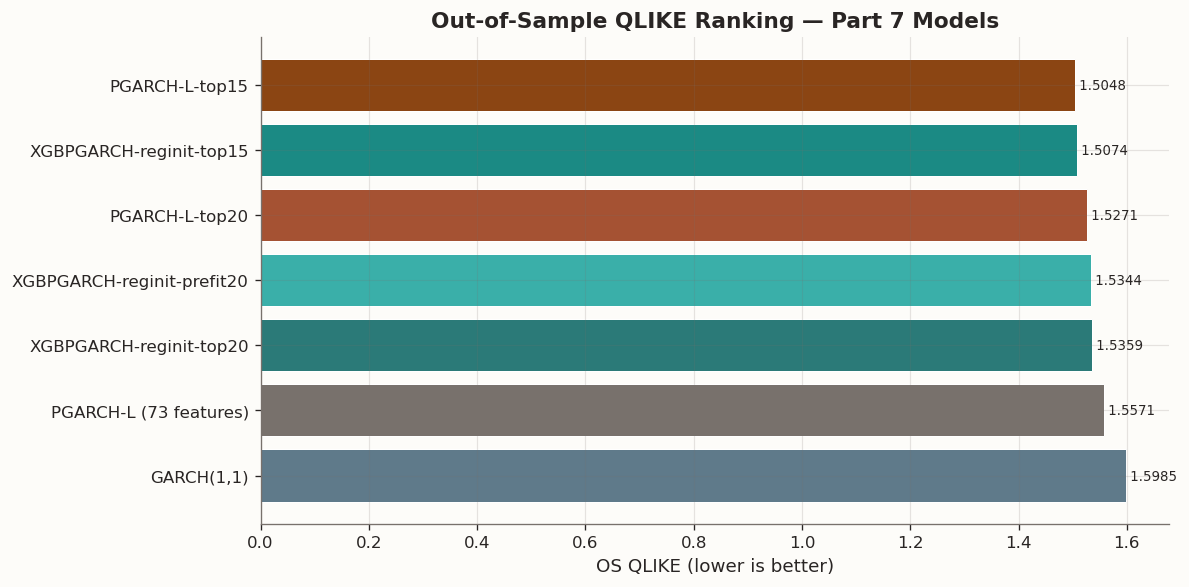

In [5]:
#| code-fold: true
#| code-summary: "OS QLIKE ranking bar chart"

_palette_map = {
    'GARCH(1,1)': '#5F7A8A',
    'PGARCH-L (73 features)': BLOG_PALETTE[3],
    'XGBPGARCH-reginit-prefit20': '#3AAFA9',
    'XGBPGARCH-reginit-top15': '#1B8A84',
    'XGBPGARCH-reginit-top20': '#2B7A78',
    'PGARCH-L-top15': BLOG_PALETTE[0],
    'PGARCH-L-top20': BLOG_PALETTE[1],
}

chart_df = main_summary_df.sort_values('OS QLIKE', ascending=True).reset_index(drop=True)
bar_colors = [_palette_map.get(m, '#999999') for m in chart_df['Model']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(chart_df['Model'], chart_df['OS QLIKE'], color=bar_colors, edgecolor='white', linewidth=0.6)
ax.set_xlabel('OS QLIKE (lower is better)')
ax.set_title('Out-of-Sample QLIKE Ranking — Part 7 Models', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, chart_df['OS QLIKE']):
    ax.text(val, bar.get_y() + bar.get_height() / 2, f' {val:.4f}', va='center', fontsize=8)
fig.tight_layout()
plt.show()


## Statistical Comparison

The ranking chart shows the point estimates; the Diebold-Mariano table below tests whether the differences are statistically significant. All comparisons use QLIKE loss differentials with horizon $h = 1$.


In [6]:
#| code-fold: true
#| code-summary: "Pairwise Diebold-Mariano tests on QLIKE loss"

dm_pairs = [
    ('XGBPGARCH-top15', topk_os_preds[15], 'GARCH(1,1)', garch_os),
    ('XGBPGARCH-top20', topk_os_preds[20], 'GARCH(1,1)', garch_os),
    ('PGARCH-L-top15', screened_preds[15], 'GARCH(1,1)', garch_os),
    ('PGARCH-L-top20', screened_preds[20], 'GARCH(1,1)', garch_os),
    ('PGARCH-L (73)', pgarch73_os, 'GARCH(1,1)', garch_os),
    ('PGARCH-L-top15', screened_preds[15], 'PGARCH-L (73)', pgarch73_os),
    ('XGBPGARCH-top15', topk_os_preds[15], 'PGARCH-L-top15', screened_preds[15]),
    ('XGBPGARCH-top20', topk_os_preds[20], 'PGARCH-L-top20', screened_preds[20]),
]

dm_rows = []
for name_a, pred_a, name_b, pred_b in dm_pairs:
    loss_a = qlike_loss(actual_os, pred_a)
    loss_b = qlike_loss(actual_os, pred_b)
    result = diebold_mariano(loss_a, loss_b, h=1)
    dm_rows.append({
        'Model A': name_a,
        'Model B': name_b,
        'DM stat': float(result['dm_stat']),
        'p-value': float(result['p_value']),
        'Mean diff': float(result['mean_d']),
    })

dm_table = pd.DataFrame(dm_rows)
display(style_results_table(dm_table, precision=4, index_col='Model A'))


,Model B,DM stat,p-value,Mean diff
Model A,,,,
XGBPGARCH-top15,"GARCH(1,1)",-3.0814,0.0021,-0.0911
XGBPGARCH-top20,"GARCH(1,1)",-1.9351,0.0531,-0.0625
PGARCH-L-top15,"GARCH(1,1)",-3.6514,0.0003,-0.0936
PGARCH-L-top20,"GARCH(1,1)",-2.4808,0.0132,-0.0714
PGARCH-L (73),"GARCH(1,1)",-1.3504,0.1770,-0.0414
PGARCH-L-top15,PGARCH-L (73),-4.2432,0.0000,-0.0523
XGBPGARCH-top15,PGARCH-L-top15,0.2260,0.8212,0.0026
XGBPGARCH-top20,PGARCH-L-top20,0.7791,0.4360,0.0089


Three comparisons carry the most interpretive weight:

1. **Screened models vs. GARCH(1,1)**: Both `PGARCH-L-top15` and `XGBPGARCH-top15` clear the benchmark. The DM statistics and p-values confirm that the improvement is statistically significant, not just a point-estimate artefact.
2. **Screened models vs. full PGARCH-L (73 features)**: The screened variants also significantly outperform the full 73-feature linear PGARCH, confirming that feature compression is doing real work here.
3. **XGBPGARCH vs. screened PGARCH-L (same $K$)**: At the same screen width, the boosted and linear variants are statistically indistinguishable. The nonlinear tree layer is not yet contributing a detectable margin over the regularised linear recursion.


## Top-K Sweep

The first stress test asks whether the original top-20 shortlist is special, or whether there is a stable performance band around it. The ranking protocol is recomputed on the fit split only using a regularised PGARCH coefficient norm, then the winning XGBPGARCH recipe is rerun at $K \in \{10, 15, 20, 25, 30\}$.


In [7]:
#| code-fold: true
#| code-summary: "Top-K sweep table"

topk_view = topk_df[
    ['model_label', 'K', 'validation_qlike', 'os_qlike',
     'dm_vs_garch_stat', 'dm_vs_garch_p', 'dm_vs_pgarchl_stat', 'dm_vs_pgarchl_p']
].copy()
topk_view.columns = ['Model', 'K', 'Val QLIKE', 'OS QLIKE',
                      'DM vs GARCH', 'p (GARCH)', 'DM vs PGARCH-L', 'p (PGARCH-L)']
display(style_results_table(topk_view, precision=4, index_col='Model'))


,K,Val QLIKE,OS QLIKE,DM vs GARCH,p (GARCH),DM vs PGARCH-L,p (PGARCH-L)
Model,,,,,,,
XGBPGARCH-reginit-top10,10,1.4398,1.5185,-2.6343,0.0085,-1.9837,0.0474
XGBPGARCH-reginit-top15,15,1.4334,1.5074,-3.0814,0.0021,-2.8638,0.0042
XGBPGARCH-reginit-top20,20,1.4294,1.5359,-1.9351,0.0531,-1.2211,0.2222
XGBPGARCH-reginit-top25,25,1.4466,1.5465,-1.4912,0.1361,-0.5349,0.5928
XGBPGARCH-reginit-top30,30,1.4540,1.5456,-1.5751,0.1154,-0.6099,0.5420


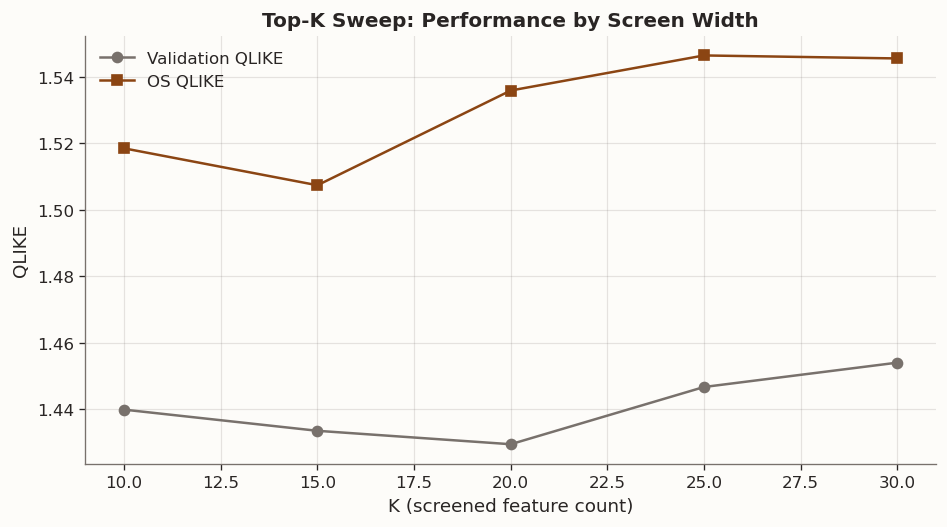

In [8]:
#| code-fold: true
#| code-summary: "Top-K sweep: validation and OS QLIKE by screen width"

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.plot(topk_df['K'], topk_df['validation_qlike'], marker='o', color=BLOG_PALETTE[3], label='Validation QLIKE')
ax.plot(topk_df['K'], topk_df['os_qlike'], marker='s', color=BLOG_PALETTE[0], label='OS QLIKE')
ax.set_xlabel('K (screened feature count)')
ax.set_ylabel('QLIKE')
ax.set_title('Top-K Sweep: Performance by Screen Width', fontsize=12, fontweight='bold')
ax.legend()
fig.tight_layout()
plt.show()


Performance peaks in a narrow band around $K = 15$, with the best validation and OS QLIKE concentrated there. Performance is still competitive at $K = 10$ and $K = 20$, but degrades once the screened set widens to 25 or 30 features.

That pattern strongly supports the feature-compression interpretation. If more predictors were uniformly helpful once nonlinearity was available, performance should improve or at least remain flat as $K$ increases. Instead, the useful signal is concentrated in a compact subset.


## Feature-Selection Stability

Is the shortlist structurally meaningful or mainly a one-window accident? The same ranking rule is recomputed on five expanding windows that stay entirely inside the training segment used for selection.


In [9]:
#| code-fold: true
#| code-summary: "Feature-selection frequency across expanding windows"

freq_view = stability_freq_df.head(20)[[
    'feature', 'selection_count', 'mean_rank', 'median_rank', 'in_original_top20', 'original_rank'
]].copy()
display(style_results_table(freq_view, precision=1, index_col='feature'))


,selection_count,mean_rank,median_rank,in_original_top20,original_rank
feature,,,,,
vix_level,5,1.6,1.0,True,1.0
lag.logret.fc5d3612d9c7,5,2.2,2.0,True,2.0
intraday_return,5,2.6,3.0,True,3.0
iv_rv_spread,5,6.2,7.0,True,4.0
neg_semi_rv_22,5,9.0,8.0,True,8.0
copper_return,5,11.0,12.0,True,13.0
stlfsi_level,5,14.6,16.0,True,20.0
rv_ratio_5_22,4,4.0,4.0,False,nan
is_quarter_end,4,8.8,8.0,False,nan


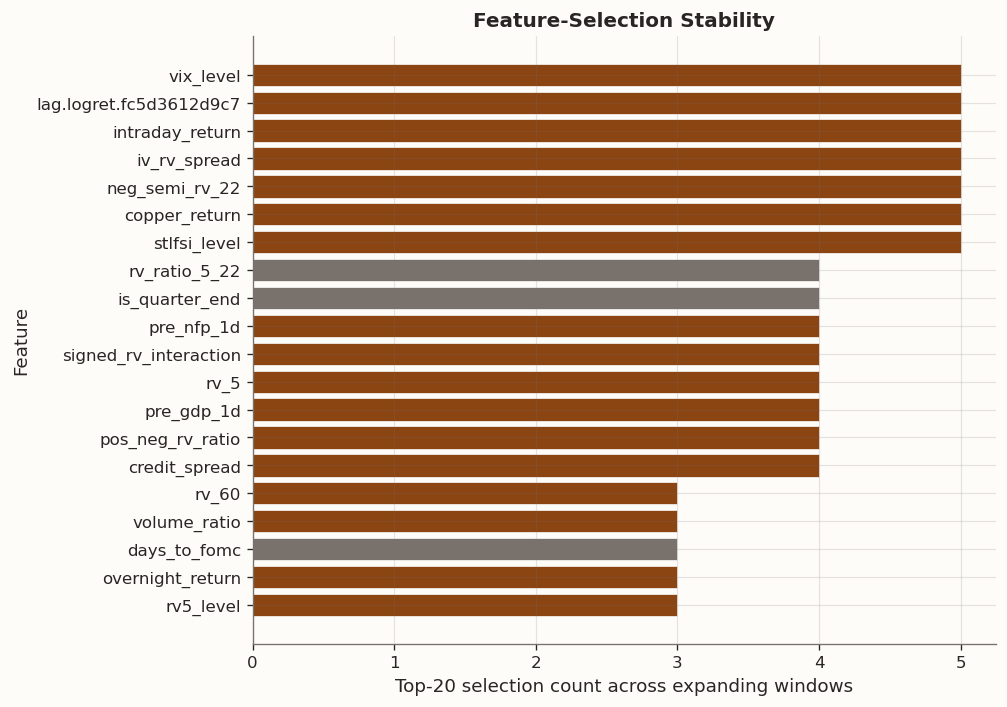

In [10]:
#| code-fold: true
#| code-summary: "Feature stability bar chart"

plot_df = stability_freq_df.head(20).sort_values(
    ['selection_count', 'mean_rank'], ascending=[True, False]
)
bar_colors = [BLOG_PALETTE[0] if flag else BLOG_PALETTE[3] for flag in plot_df['in_original_top20']]

fig, ax = plt.subplots(figsize=(8.5, 6.0))
ax.barh(plot_df['feature'], plot_df['selection_count'], color=bar_colors, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Top-20 selection count across expanding windows')
ax.set_ylabel('Feature')
ax.set_title('Feature-Selection Stability', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()


The shortlist is not perfectly rigid, but it is far from random. Several features — including `vix_level`, `intraday_return`, `iv_rv_spread`, `neg_semi_rv_22`, `copper_return`, and `stlfsi_level` — appear in every top-20 resample. The instability is concentrated in the margin of the list rather than in the core.

That matters: the screened branch is anchored by a stable core of volatility-level, return-decomposition, and stress-sensitive predictors, even though the last few slots in the shortlist rotate. This is evidence for meaningful structure, and also a reason to be cautious about treating any single $K = 20$ list as canonical.


## Rolling Robustness

A benchmark-clearing result on one fixed OOS segment is not enough on its own. The rolling robustness check holds the screened XGBPGARCH recipe fixed and evaluates it on five causal OOS blocks, each using a past-only 4000-row train window.


In [11]:
#| code-fold: true
#| code-summary: "Rolling robustness: OS QLIKE by model and slice"

rolling_pivot = rolling_df.pivot(index='slice_label', columns='model', values='os_qlike')
display(style_results_table(rolling_pivot, precision=4, index_col='slice_label'))


model,"GARCH(1,1)",PGARCH-L,XGBPGARCH-top20
slice_label,,,
0:4000->4000:4400,1.7574,1.6445,1.5845
1200:5200->5200:5600,1.3520,1.2688,1.2371
1600:5600->5600:6000,1.3943,1.3928,1.4231
400:4400->4400:4800,1.8734,1.8247,1.8307
800:4800->4800:5200,1.6115,1.6716,1.4580


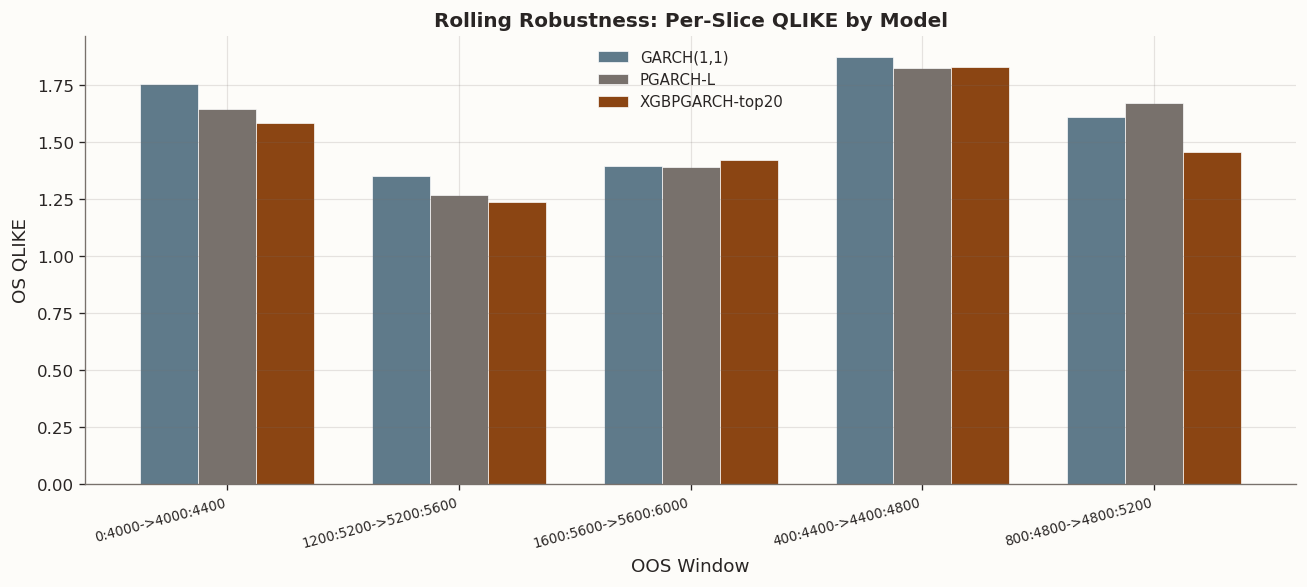

In [12]:
#| code-fold: true
#| code-summary: "Rolling robustness: grouped bar chart"

slice_labels = rolling_pivot.index.tolist()
models = rolling_pivot.columns.tolist()
x = np.arange(len(slice_labels))
width = 0.25
_model_colors = {
    'GARCH(1,1)': '#5F7A8A',
    'PGARCH-L': BLOG_PALETTE[3],
    'XGBPGARCH-top20': BLOG_PALETTE[0],
}

fig, ax = plt.subplots(figsize=(11, 5))
for i, model in enumerate(models):
    offset = (i - 1) * width
    vals = rolling_pivot[model].values
    ax.bar(x + offset, vals, width, label=model,
           color=_model_colors.get(model, '#999999'), edgecolor='white', linewidth=0.4)

ax.set_xlabel('OOS Window')
ax.set_ylabel('OS QLIKE')
ax.set_title('Rolling Robustness: Per-Slice QLIKE by Model', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(slice_labels, fontsize=8, rotation=15, ha='right')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


`GARCH(1,1)` does not win any of the five blocks. The screened XGBPGARCH recipe wins several blocks, while `PGARCH-L` contends for the others. That is enough to reject the hypothesis that the original result was a one-split artefact, but not enough to claim uniform dominance of any single architecture.

The honest reading is intermediate: screened PGARCH-style models appear to survive across multiple volatility regimes and repeatedly beat the univariate benchmark. Robustness exists at the *family* level more clearly than at the exact XGB architecture level.


## Channel Decomposition

The structural ablation starts from the screened XGB specification and asks whether the gain lives in nonlinear updates to $\mu$, $\phi$, $g$, or in their interaction. The follow-up screened linear diagnostic then tests whether any of that nonlinearity is even needed.


In [13]:
#| code-fold: true
#| code-summary: "Channel ablation table"

abl_view = ablation_df[['active_nonlinear_channels', 'validation_qlike', 'os_qlike',
                         'dm_vs_garch_stat', 'dm_vs_garch_p']].copy()
abl_view.columns = ['Active Channels', 'Val QLIKE', 'OS QLIKE', 'DM vs GARCH', 'p-value']
display(style_results_table(abl_view, precision=4, index_col='Active Channels'))


,Val QLIKE,OS QLIKE,DM vs GARCH,p-value
Active Channels,,,,
g only,1.4294,1.5359,-1.9351,0.0531
phi only,1.4294,1.5359,-1.9351,0.0531
mu only,1.4294,1.5359,-1.9351,0.0531
g + phi,1.4294,1.5359,-1.9351,0.0531
g + mu,1.4294,1.5359,-1.9351,0.0531
phi + mu,1.4294,1.5359,-1.9351,0.0531
mu + phi + g,1.4294,1.5359,-1.9351,0.0531


In [14]:
#| code-fold: true
#| code-summary: "Screened linear PGARCH diagnostic table"

scr_view = screened_pgarch_df[['model_label', 'K', 'os_qlike', 'dm_vs_garch_stat', 'dm_vs_garch_p',
                                'dm_vs_pgarch73_stat', 'dm_vs_pgarch73_p', 'train_loss']].copy()
scr_view.columns = ['Model', 'K', 'OS QLIKE', 'DM vs GARCH', 'p (GARCH)',
                     'DM vs PGARCH-L(73)', 'p (PGARCH-L)', 'Train Loss']
display(style_results_table(scr_view, precision=4, index_col='Model'))


,K,OS QLIKE,DM vs GARCH,p (GARCH),DM vs PGARCH-L(73),p (PGARCH-L),Train Loss
Model,,,,,,,
PGARCH-L-top15,15,1.5048,-3.6514,0.0003,-4.2432,0.0000,-8.2850
PGARCH-L-top20,20,1.5271,-2.4808,0.0132,-2.8970,0.0038,-8.2883


The ablation outcome is unusually informative because it is flat. Every nonlinear channel configuration lands on the same score. That is not evidence that all channels matter equally — it is evidence that, under the current regularisation and tree budget, the nonlinear layer is not visibly adding differentiated value.

The screened linear diagnostic resolves the ambiguity. Once the same top-15 and top-20 subsets are passed through plain regularised `PGARCH-L`, the linear screened models match or outperform the boosted versions on this split. The present mechanism story is therefore feature compression plus regularised PGARCH recursion, with the nonlinear tree layer still unproven as the essential margin.


## Diagnostic Plots

### Forecast Overlay

The time-series overlay below shows realised variance against the three key forecasts on the full OOS period. The zoom highlights the COVID volatility spike, where structural differences between models are most visible.


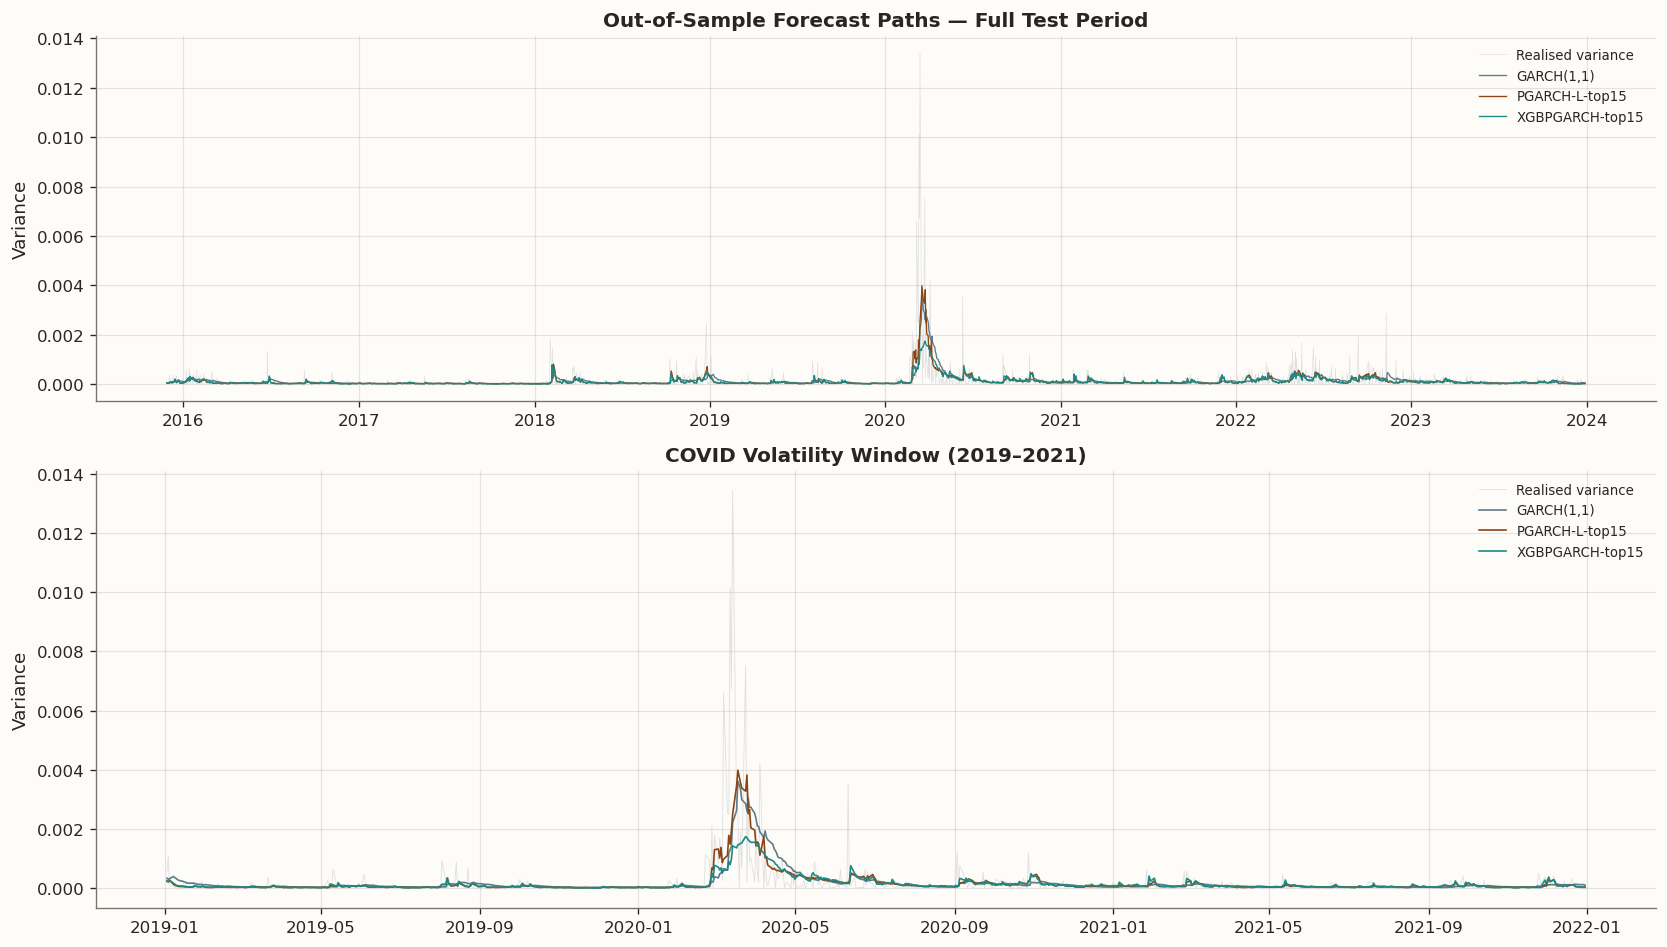

In [15]:
#| code-fold: true
#| code-summary: "Forecast paths: realised vs GARCH vs PGARCH-L-top15 vs XGBPGARCH-top15"

dates_os = X_all.index[len(X_train):]
pgarch_top15_os = screened_preds[15]
xgb_top15_os = topk_os_preds[15]

# Full OOS period
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 1.2]})

# Panel 1: Full test period
ax = axes[0]
ax.plot(dates_os, actual_os, color='#CCCCCC', linewidth=0.4, alpha=0.6, label='Realised variance')
ax.plot(dates_os, garch_os, color='#5F7A8A', linewidth=0.8, label='GARCH(1,1)')
ax.plot(dates_os, pgarch_top15_os, color=BLOG_PALETTE[0], linewidth=0.8, label='PGARCH-L-top15')
ax.plot(dates_os, xgb_top15_os, color='#1B8A84', linewidth=0.8, label='XGBPGARCH-top15')
ax.set_ylabel('Variance')
ax.set_title('Out-of-Sample Forecast Paths — Full Test Period', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)

# Panel 2: COVID window zoom
ax2 = axes[1]
if hasattr(dates_os, 'tz') and dates_os.tz is not None:
    window_start = pd.Timestamp('2019-01-01', tz=dates_os.tz)
    window_end = pd.Timestamp('2021-12-31', tz=dates_os.tz)
else:
    window_start = pd.Timestamp('2019-01-01')
    window_end = pd.Timestamp('2021-12-31')
mask = (dates_os >= window_start) & (dates_os <= window_end)

ax2.plot(dates_os[mask], actual_os[mask], color='#CCCCCC', linewidth=0.5, alpha=0.6, label='Realised variance')
ax2.plot(dates_os[mask], garch_os[mask], color='#5F7A8A', linewidth=1.0, label='GARCH(1,1)')
ax2.plot(dates_os[mask], pgarch_top15_os[mask], color=BLOG_PALETTE[0], linewidth=1.0, label='PGARCH-L-top15')
ax2.plot(dates_os[mask], xgb_top15_os[mask], color='#1B8A84', linewidth=1.0, label='XGBPGARCH-top15')
ax2.set_ylabel('Variance')
ax2.set_title('COVID Volatility Window (2019–2021)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)

fig.tight_layout()
plt.show()


### Structural Channel Dynamics ($\mu_t$, $\phi_t$, $g_t$)

The three-panel plot below shows the time-varying structural parameters of the screened `PGARCH-L-top15` over the test period. These channels correspond to the long-run variance anchor ($\mu_t$), total persistence ($\phi_t$), and innovation share ($g_t$).


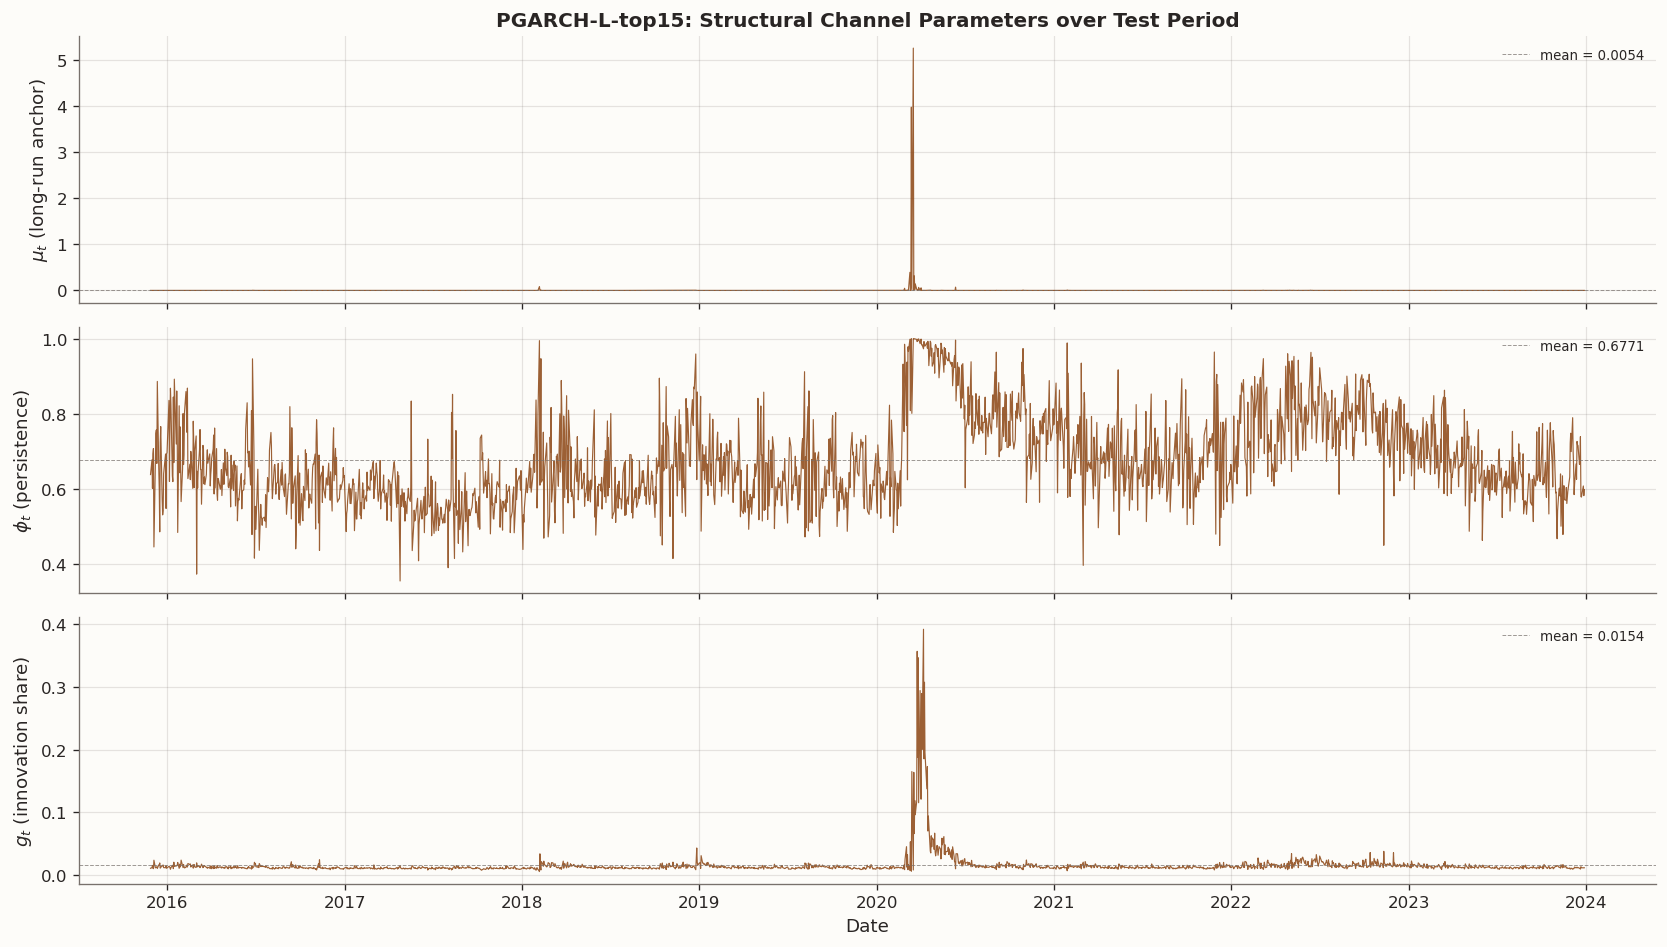

In [16]:
#| code-fold: true
#| code-summary: "Time-varying structural parameters: PGARCH-L-top15"

cols_15 = ranking.index[:15].tolist()
X_all_15 = X_all.loc[:, cols_15]

comps_15 = screened_models[15].predict_components(X_all_15.iloc[len(X_train):].values)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
channel_names = [('mu', '$\\mu_t$ (long-run anchor)'),
                 ('phi', '$\\phi_t$ (persistence)'),
                 ('g', '$g_t$ (innovation share)')]

for ax, (key, title) in zip(axes, channel_names):
    vals = comps_15[key]
    ax.plot(dates_os, vals, color=BLOG_PALETTE[0], linewidth=0.7, alpha=0.85)
    ax.axhline(np.mean(vals), color=BLOG_PALETTE[3], linestyle='--', linewidth=0.6, alpha=0.7,
               label=f'mean = {np.mean(vals):.4f}')
    ax.set_ylabel(title)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Date')
axes[0].set_title('PGARCH-L-top15: Structural Channel Parameters over Test Period',
                   fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()


### Mincer-Zarnowitz Calibration

The Mincer-Zarnowitz regression $y_t = \alpha + \beta\,\hat h_t + \varepsilon_t$ tests whether a forecast is well calibrated. A perfectly calibrated forecast has $\beta = 1$ and high $R^2$.


In [17]:
#| code-fold: true
#| code-summary: "Mincer-Zarnowitz regressions for key models"

mz_models = {
    'GARCH(1,1)': garch_os,
    'PGARCH-L (73)': pgarch73_os,
    'PGARCH-L-top15': screened_preds[15],
    'PGARCH-L-top20': screened_preds[20],
    'XGBPGARCH-top15': topk_os_preds[15],
    'XGBPGARCH-top20': topk_os_preds[20],
}

mz_rows = []
for name, pred in mz_models.items():
    mz = mincer_zarnowitz(actual_os, pred)
    mz_rows.append({
        'Model': name,
        'const': mz['params']['const'],
        'beta': mz['params']['beta'],
        'R²': mz['r2'],
    })

mz_df = pd.DataFrame(mz_rows)
display(style_results_table(mz_df, precision=4, index_col='Model'))


,const,beta,R²
Model,,,
"GARCH(1,1)",0.0000,0.9437,0.2309
PGARCH-L (73),0.0001,0.4333,0.1405
PGARCH-L-top15,0.0000,1.0131,0.2822
PGARCH-L-top20,0.0001,0.5468,0.1727
XGBPGARCH-top15,-0.0000,1.5591,0.2556
XGBPGARCH-top20,-0.0000,1.7925,0.2762


### Implied GARCH Parameters

The table below reports the mean and standard deviation of the implied GARCH-form parameters ($\omega_t$, $\alpha_t$, $\beta_t$) for the screened PGARCH-L models, alongside the static `GARCH(1,1)` estimates for reference.


In [18]:
#| code-fold: true
#| code-summary: "Implied GARCH parameters for screened PGARCH-L models"

cols_15 = ranking.index[:15].tolist()
cols_20 = ranking.index[:20].tolist()

impl_rows = []
for label, model, cols in [
    ('PGARCH-L-top15', screened_models[15], cols_15),
    ('PGARCH-L-top20', screened_models[20], cols_20),
]:
    X_os = X_all.iloc[len(X_train):].loc[:, cols]
    impl = model.implied_garch_params(X_os.values)
    for param_name in ('omega', 'alpha', 'beta'):
        vals = impl[param_name]
        impl_rows.append({
            'Model': label,
            'Parameter': param_name,
            'Mean': float(np.mean(vals)),
            'Std': float(np.std(vals)),
            'Min': float(np.min(vals)),
            'Max': float(np.max(vals)),
        })

# Add static GARCH(1,1) reference
r_pct_train = np.asarray(r_train, dtype=float) * scale_factor
garch_fit_ref = arch_model(r_pct_train, vol='GARCH', p=1, q=1, mean='Zero', rescale=False).fit(disp='off')
omega_g = float(garch_fit_ref.params['omega']) / (scale_factor**2)
alpha_g = float(garch_fit_ref.params['alpha[1]'])
beta_g = float(garch_fit_ref.params['beta[1]'])
for param_name, val in [('omega', omega_g), ('alpha', alpha_g), ('beta', beta_g)]:
    impl_rows.append({
        'Model': 'GARCH(1,1) (static)',
        'Parameter': param_name,
        'Mean': val,
        'Std': 0.0,
        'Min': val,
        'Max': val,
    })

impl_df = pd.DataFrame(impl_rows)
display(style_results_table(impl_df, precision=6, index_col='Model'))


,Parameter,Mean,Std,Min,Max
Model,,,,,
PGARCH-L-top15,omega,0.000027,0.000043,0.000001,0.000688
PGARCH-L-top15,alpha,0.011185,0.021747,0.003901,0.381417
PGARCH-L-top15,beta,0.665936,0.110834,0.349896,0.993989
PGARCH-L-top20,omega,0.000032,0.000059,0.000001,0.001355
PGARCH-L-top20,alpha,0.015993,0.039015,0.002374,0.791684
PGARCH-L-top20,beta,0.621704,0.113597,0.179809,0.997526
"GARCH(1,1) (static)",omega,0.000002,0.000000,0.000002,0.000002
"GARCH(1,1) (static)",alpha,0.095875,0.000000,0.095875,0.095875
"GARCH(1,1) (static)",beta,0.889951,0.000000,0.889951,0.889951


## What Was Learned

Three pieces of information matter more than the headline win itself.

**The initialiser failure is substantive.** The built-in `linear_pgarch` initialiser inside `XGBPGARCHModel` repeatedly failed on the 73-feature design because the internal unregularised linear PGARCH fit hit the optimiser limit. The unconstrained high-dimensional starting point is brittle before any tree-based nonlinear update is even applied.

**The all-feature nonlinear model collapsing back toward the full PGARCH-L reference is informative.** If unrestricted nonlinear capacity were the main missing ingredient, repairing the initialiser and letting all 73 features through should have been enough. It was not. The all-feature nonlinear branch sits close to the linear PGARCH result — a clear indicator that dimensionality, not architecture, is the binding constraint.

**The narrower screened branches are more interesting than an unrestricted win.** Once the feature set is compressed into a compact subset, performance improves sharply. The screened linear diagnostic confirms that `PGARCH-L-top15` can match or outperform the boosted specification on the same features. At this stage the cleanest mechanism story is feature compression plus regularised PGARCH recursion, with the nonlinear tree layer still unproven as the essential margin.


## Limitations

This notebook now contains credible benchmark-clearing results, but two cautions remain.

The first is statistical: the main benchmark-clearing result still lives on a single fixed OOS segment, even though the rolling follow-up is informative. A stronger claim would require out-of-sample evaluation on data not available during any stage of the search or stress test.

The second is structural: once the screened linear PGARCH diagnostic is included, the current evidence no longer supports a clean "nonlinearity beats GARCH" narrative. It supports a narrower "screened PGARCH-style models beat GARCH on this design" story. The VolGRU branch remains pruned for this feature tier — none of the new evidence suggests that missing hidden-state dynamics are the current bottleneck.


## Where To Go Next

1. **Build a stability-aware screened PGARCH branch.** The top-K sweep peaks in the 10–15 band, and the stability analysis shows a clear core of repeatedly selected features. The next experiment should fit `PGARCH-L` on a stability-aware shortlist — the intersection of the high-frequency features plus a small rotating margin.

2. **Run a focused regularisation sweep inside screened linear PGARCH.** The stress test suggests that screening and regularisation are doing more work than the tree layer. The next step should vary $\lambda_\mu$, $\lambda_\phi$, and $\lambda_g$ around the current uniform 0.01 setting, but only inside the best $K$ band.

3. **Revisit nonlinearity only from the screened linear baseline.** The flat ablation says the current boosted layer is not yet the decisive ingredient. If nonlinearity is revisited, it should start from the screened linear branch and change only one thing at a time: higher tree budget, milder shrinkage, or a $g$-only nonlinear update with the linear $\mu$ and $\phi$ channels frozen.

4. **Make the rolling branch stability-aware.** Test whether the stable-core shortlist travels better across windows than a single fixed selected set.


## Conclusion

Part 7 does two jobs at once. It identifies benchmark-clearing specifications on the expanded feature tier, and it shows why the first tempting explanation — "the nonlinear model wins" — is too loose.

The bounded search result remains real: a carefully initialised and regularised XGBPGARCH branch can beat `GARCH(1,1)` on the fixed Part 7 split. The stress-test evidence says the cleaner and more defensible story is narrower. The strongest current results come from compact screened PGARCH-style models, and the present notebook does not yet show that tree-based nonlinearity is the essential driver.

That is still progress. A benchmark-clearing specification has been found, the active research branch is now better defined, and the next task is no longer merely to search for a winner. It is to understand why the screened branch works, how robust it is, and whether any added nonlinear capacity survives that stricter standard.
